In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score 
from sklearn.metrics import r2_score

In [15]:
#CLEANING DATA########

In [16]:
df = pd.read_csv('kc_house_data.csv')



In [17]:
# Dataset disalin ke train_df agar data asli tidak berubah saat proses cleaning.

train_df = df.copy()

df.shape, train_df.shape


((21613, 21), (21613, 21))

In [18]:
train_df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [19]:
# Kolom id dan date dihapus karena tidak terlalu membantu dalam prediksi harga rumah.

train_df.drop(['id','date'], axis=1, inplace=True)
train_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [20]:
train_df.info

<bound method DataFrame.info of           price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0      221900.0         3       1.00         1180      5650     1.0   
1      538000.0         3       2.25         2570      7242     2.0   
2      180000.0         2       1.00          770     10000     1.0   
3      604000.0         4       3.00         1960      5000     1.0   
4      510000.0         3       2.00         1680      8080     1.0   
...         ...       ...        ...          ...       ...     ...   
21608  360000.0         3       2.50         1530      1131     3.0   
21609  400000.0         4       2.50         2310      5813     2.0   
21610  402101.0         2       0.75         1020      1350     2.0   
21611  400000.0         3       2.50         1600      2388     2.0   
21612  325000.0         2       0.75         1020      1076     2.0   

       waterfront  view  condition  grade  sqft_above  sqft_basement  \
0               0     0          3      7  

In [21]:
#menghapus kolom yang tidak di pakai
train_df.drop(['id','date'], axis=1, errors='ignore', inplace=True)

In [22]:
#mengecek apakah ada data yang kosong (missing value) pada setiap kolom.
train_df.isna().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [23]:
#mengambil semua kolom yang bertipe numerik.

numerical_col = [feature for feature in train_df.columns if train_df[feature].dtype != 'object']
# if train_df[feature].dtype != 'object'
# Kondisi ini digunakan untuk menyaring hanya kolom yang bukan bertipe object.
# Dalam pandas, tipe object biasanya berarti data teks/string.
# Jadi, kondisi ini memastikan hanya kolom numerik (int, float, dsb.) yang masuk ke list
numerical_col

['price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

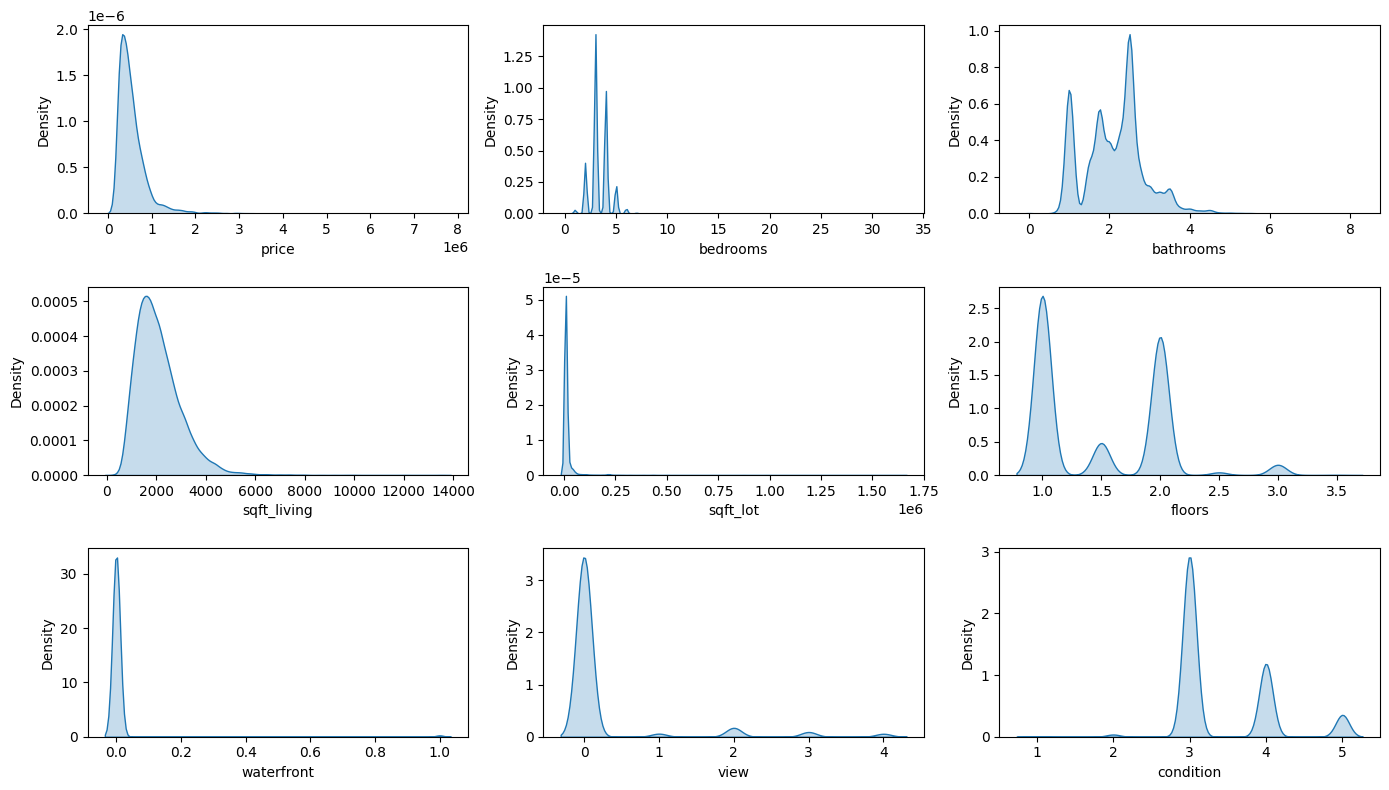

In [24]:

#Melihat Distribusi Data Melihat Distribusi Data
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14,8))

for i, column in enumerate(numerical_col[:9]):
    
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    
    sns.kdeplot(data=train_df[column], ax=ax, fill=True)

plt.tight_layout()
plt.show()

In [25]:
# 1️⃣ price

# Distribusi harga rumah terlihat miring ke kanan (right skewed).
# Artinya sebagian besar rumah memiliki harga menengah, tetapi ada beberapa rumah yang memiliki harga sangat tinggi.

# Ini menandakan kemungkinan terdapat outlier pada harga rumah.

# 2️⃣ bedrooms

# Jumlah kamar tidur paling banyak berada pada kisaran 3–4 kamar.
# Namun terlihat ada nilai yang cukup tinggi (misalnya lebih dari 10 kamar) yang kemungkinan merupakan outlier.

# 3️⃣ bathrooms

# Jumlah kamar mandi paling banyak berada pada kisaran 2–3 kamar mandi, yang merupakan jumlah yang umum untuk rumah.

# 4️⃣ sqft_living

# Ukuran rumah yang paling umum berada pada kisaran 1500–3000 sqft, tetapi terlihat ada rumah yang sangat besar sehingga distribusinya memanjang ke kanan.

# Ini juga menunjukkan kemungkinan outlier.

# 5️⃣ sqft_lot

# Distribusinya sangat tajam di nilai kecil, namun ada nilai yang sangat besar.
# Ini berarti terdapat tanah dengan ukuran yang jauh lebih besar dari rumah lainnya.


# 6️⃣ floors

# Sebagian besar rumah memiliki 1 atau 2 lantai, yang merupakan jumlah lantai yang paling umum.

# 7️⃣ waterfront

# Nilai pada kolom ini hampir semuanya 0, yang berarti sebagian besar rumah tidak berada di dekat air.

In [26]:
# Dari grafik distribusi ini kita dapat melihat bahwa beberapa fitur memiliki nilai ekstrem atau outlier, seperti:

# price
# sqft_living
# sqft_lot

# Oleh karena itu langkah selanjutnya adalah mendeteksi outlier menggunakan boxplot.

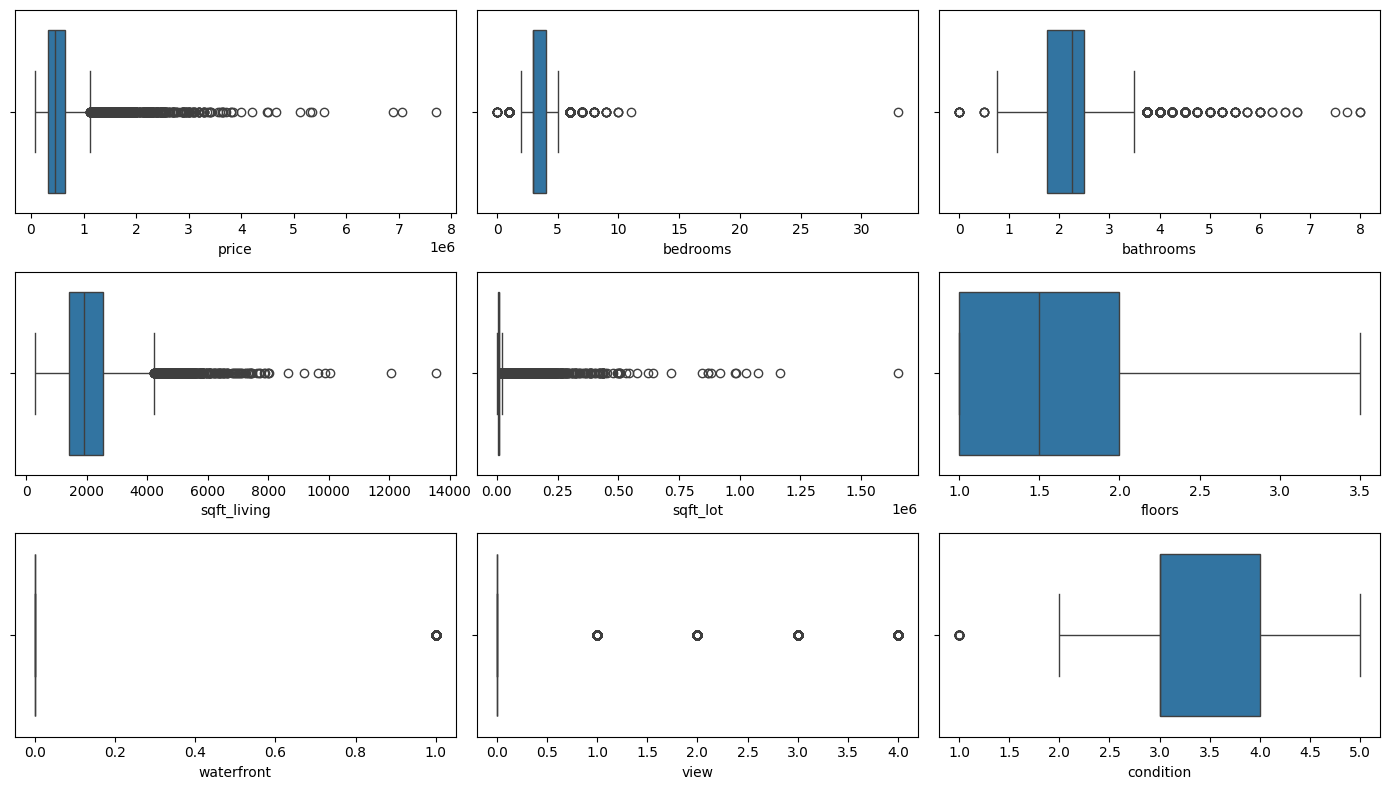

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14,8))

for i, column in enumerate(numerical_col[:9]):
    
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    
    sns.boxplot(x=train_df[column], ax=ax)

plt.tight_layout()
plt.show()

In [27]:
# 1️⃣ price

# Terlihat sangat banyak titik di sebelah kanan.

# Artinya:

# banyak rumah dengan harga sangat tinggi

# Ini merupakan outlier.

# 2️⃣ bedrooms

# Sebagian besar rumah memiliki:

# 3 - 5 kamar tidur

# Namun terlihat nilai ekstrem seperti:

# >10 kamar

# Ini kemungkinan outlier.

# 3️⃣ bathrooms

# Mayoritas rumah memiliki:

# 2 - 3 kamar mandi

# Beberapa nilai lebih dari 5 juga terlihat sebagai outlier.

# 4️⃣ sqft_living

# Sebagian besar rumah berada di kisaran:

# 1000 – 3000 sqft

# Tetapi ada rumah dengan ukuran sangat besar seperti:

# >10000 sqft

# Ini jelas outlier.

# 5️⃣ sqft_lot

# Ini adalah kolom dengan outlier paling ekstrem.

# # Beberapa rumah memiliki ukuran tanah yang sangat besar dibanding lainnya.

In [28]:
# Kesimpulan

# Beberapa kolom memiliki outlier yang cukup banyak, terutama:

# price
# sqft_living
# sqft_lot
# sqft_above
# sqft_basement

# Oleh karena itu kita akan menghapus outlier menggunakan metode IQR.

In [29]:

# Membuat Fungsi Menghapus Outlier

def remove_outlier_iqr(data, col):

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col] > lower_bound) & (data[col] < upper_bound)]



# Langkah yang dilakukan fungsi ini:

# 1️⃣ Menghitung Q1 (25%)
# 2️⃣ Menghitung Q3 (75%)
# 3️⃣ Menghitung IQR

# IQR = Q3 - Q1
# 4️⃣ Menentukan batas bawah dan batas atas

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# 5️⃣ Menghapus data yang berada di luar batas tersebut.

In [30]:

# Menghapus Outlier
important_col = ['price','sqft_living','sqft_lot','sqft_above','sqft_basement']

for col in important_col:

    train_df = remove_outlier_iqr(train_df, col)

# Pada cell ini kita menghapus outlier pada beberapa kolom penting.

# Kolom yang dipilih adalah:

# price
# sqft_living
# sqft_lot
# sqft_above
# sqft_basement

# Karena kolom tersebut memiliki nilai ekstrem yang dapat mempengaruhi model Machine Learning.

# Dengan menghapus outlier, model biasanya akan menjadi lebih stabil dan akurat.

In [31]:
train_df.shape

(17240, 19)

In [32]:
#BUILD AI MODEL########

In [33]:
#Memisahkan Feature dan Target
x = train_df.drop('price', axis=1)
y = train_df['price']

x.head()

# memisahkan dataset menjadi:

# Feature (X)
# yaitu semua variabel yang digunakan untuk memprediksi harga rumah.


# Target (y)
# yaitu nilai yang ingin diprediksi, yaitu:
# price (harga rumah)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [34]:
#Membagi Data Training dan Testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42
)

# Dataset dibagi menjadi dua bagian:

# Training data
# digunakan untuk melatih model.

# Testing data
# digunakan untuk menguji performa model.

# Proporsi pembagian:

# 80% training
# 20% testing

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [36]:
#Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)
res = r2_score(y_test, y_pred)
print(res)

# Pada cell ini kita membuat model Linear Regression.

# Langkah yang dilakukan:

# 1️⃣ Melatih model dengan data training
# 2️⃣ Melakukan prediksi pada data testing
# 3️⃣ Menghitung nilai R² Score

# R² Score menunjukkan seberapa baik model memprediksi data.

0.6739765433304414


In [ ]:
#Model 2: Linear Regression
dt_model = DecisionTreeRegressor()
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)
res = r2_score(y_test, y_pred)
print(res)

# Pada cell ini kita menggunakan algoritma Decision Tree Regressor.

# Model ini bekerja dengan membuat pohon keputusan untuk memprediksi harga rumah berdasarkan fitur yang ada.

0.7019948532113017


In [37]:
#model 1: Desion Tree Regressor
dt_model = DecisionTreeRegressor()

dt_model.fit(x_train, y_train)

y_pred = dt_model.predict(x_test)

res = r2_score(y_test, y_pred)


print(res)

0.7178787331584818


In [38]:
#Model 3: Random Forest
rf_model = RandomForestRegressor()

rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)

res = r2_score(y_test, y_pred)

print(res)

0.8666178137851211


In [40]:
#Model 4: XGBoost
import xgboost as xgb

model = xgb.XGBRegressor()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

res = r2_score(y_test, y_pred)

print(res)

0.8737284485259


In [41]:
#Cross Validation
from sklearn.model_selection import cross_val_score

dt_model = DecisionTreeRegressor()

score = cross_val_score(dt_model, x, y, cv=5, scoring='r2')

print('cross_val_score: ', score, score.mean(), score.std())

cross_val_score:  [0.72435181 0.71297584 0.70481464 0.73561864 0.70893455] 0.7173390947406896 0.011223690086359981


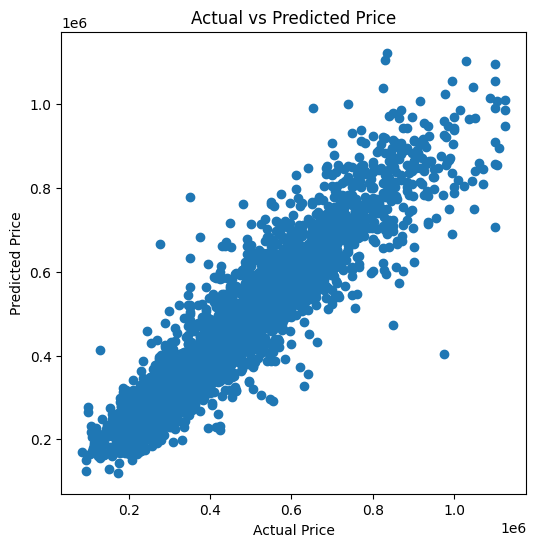

In [42]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

In [ ]:
#Menghitung Score Training dan Testing
train_score = rf_model.score(x_train, y_train)
test_score = rf_model.score(x_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9780862343499692
Test R2: 0.8666178137851211


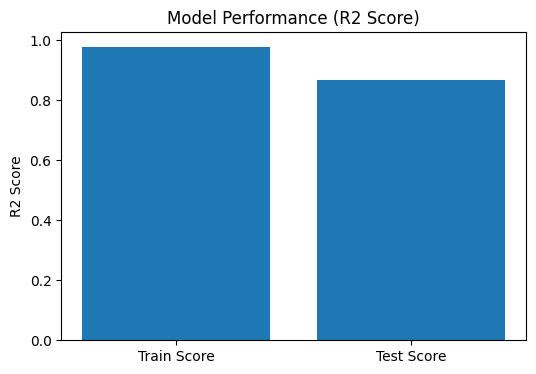

In [48]:
#📦 Cell — Grafik Perbandingan Train vs Test
scores = [train_score, test_score]
labels = ['Train Score', 'Test Score']

plt.figure(figsize=(6,4))
plt.bar(labels, scores)

plt.title("Model Performance (R2 Score)")
plt.ylabel("R2 Score")

plt.show()